In [5]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import load_model


model = load_model('best_model.keras')


In [6]:
test_datagen = ImageDataGenerator(rescale=1./255)

test_generator = test_datagen.flow_from_directory(
    'data/test',  
    target_size=(128, 128),  
    batch_size=32,
    class_mode='categorical', 
    shuffle=False  
)

Found 7178 images belonging to 7 classes.


In [7]:
test_loss, test_acc = model.evaluate(test_generator)
print(f'Test Loss: {test_loss}')
print(f'Test Accuracy: {test_acc}')

C:\dataanalisis\envs\abyan\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


225/225 ━━━━━━━━━━━━━━━━━━━━ 16s 71ms/step - accuracy: 0.5121 - loss: 1.2487
Test Loss: 1.109835147857666
Test Accuracy: 0.5777375102043152


225/225 ━━━━━━━━━━━━━━━━━━━━ 15s 65ms/step


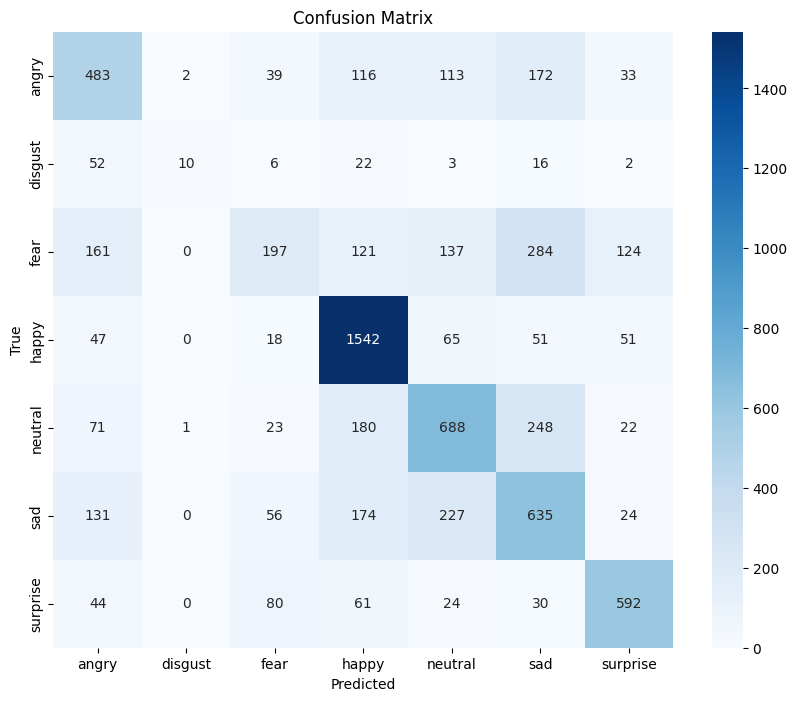

In [9]:
y_true = test_generator.classes  
y_pred = model.predict(test_generator, verbose=1) 
y_pred_classes = np.argmax(y_pred, axis=1) 

cm = confusion_matrix(y_true, y_pred_classes)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=test_generator.class_indices.keys(), yticklabels=test_generator.class_indices.keys())
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 138ms/step


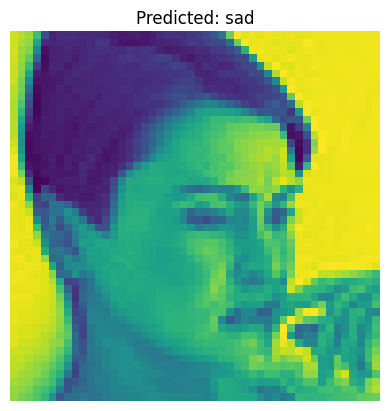

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step


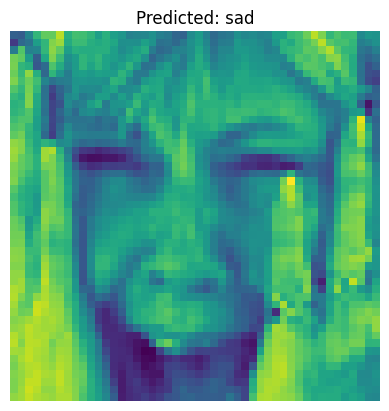

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step


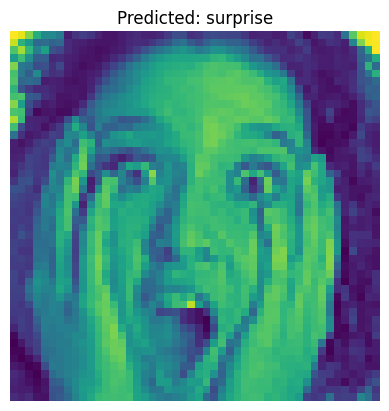

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step


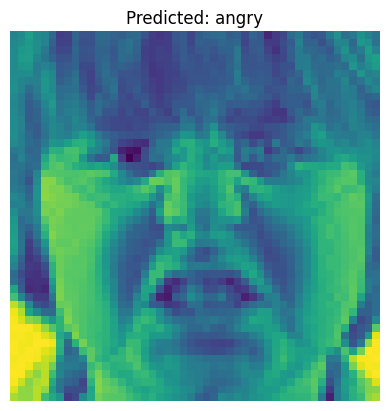

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step


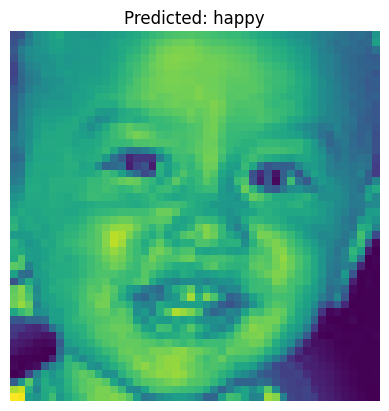

In [12]:
for i in range(5):  
    index = random.randint(0, len(test_generator.filenames)-1)
    img_path = test_generator.filenames[index]  
    img = plt.imread('data/test/' + img_path)  

  
    img_resized = image.load_img('data/test/' + img_path, target_size=(128, 128))
    img_resized = image.img_to_array(img_resized)  
    img_resized = np.expand_dims(img_resized, axis=0)  
    img_resized = img_resized / 255.0  

   
    pred = model.predict(img_resized)
    class_pred = np.argmax(pred, axis=1)

    
    plt.imshow(img)  
    plt.axis('off')


    class_pred_label = list(test_generator.class_indices.keys())[class_pred[0]] 
    plt.title(f'Predicted: {class_pred_label}')
    plt.show()

In [13]:
report = classification_report(y_true, y_pred_classes, target_names=test_generator.class_indices.keys())
print(report)

              precision    recall  f1-score   support

       angry       0.49      0.50      0.50       958
     disgust       0.77      0.09      0.16       111
        fear       0.47      0.19      0.27      1024
       happy       0.70      0.87      0.77      1774
     neutral       0.55      0.56      0.55      1233
         sad       0.44      0.51      0.47      1247
    surprise       0.70      0.71      0.71       831

    accuracy                           0.58      7178
   macro avg       0.59      0.49      0.49      7178
weighted avg       0.57      0.58      0.56      7178



In [1]:
import cv2
import numpy as np
from tensorflow.keras.preprocessing import image
from tensorflow.keras.models import load_model
import matplotlib.pyplot as plt


model = load_model('best_model.keras')  


cap = cv2.VideoCapture(0)


emotion_labels = ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']

while True:
   
    ret, frame = cap.read()
    if not ret:
        print("Tidak dapat mengakses kamera")
        break


    img = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)  
    img = cv2.resize(img, (128, 128))  
    img_array = image.img_to_array(img)  
    img_array = np.expand_dims(img_array, axis=0)  
    img_array = img_array / 255.0  

    
    pred = model.predict(img_array)
    class_pred = np.argmax(pred, axis=1)
    predicted_emotion = emotion_labels[class_pred[0]]  

   
    cv2.putText(frame, f'Predicted Emotion: {predicted_emotion}', (10, 30),
                cv2.FONT_HERSHEY_SIMPLEX, 1, (255, 0, 0), 2, cv2.LINE_AA)

  
    cv2.imshow('Emotion Recognition', frame)


    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

cap.release()
cv2.destroyAllWindows()


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 163ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━